# Laboratorio 1 - Exploración, preparación y regresión lineal

## AlpesPlanck

**Integrantes:**
- Daniel Esteban Pardo Pardo
- Samuel Andrés Molina Luna

**Curso:** ISIS2611 - Aprendizaje de Máquina
**Fecha:** 31 de Agosto 2026

# 1. Contexto
El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su estación de Jena, Alemania, desde 2003. A partir de un histórico de datos que se nos ha proporcionado, realizaremos una exploración de los mismos para entender su composición y validar los principios de calidad (unicidad, completitud, validez y consistencia) estudiados en el curso. <br><br>
De esta manera podremos llevar a cabo un proceso de ingeniería de datos que nos permitirá preparar los datos proporcionados para, finalmente, elaborar dos modelos de **regresión lineal** con el uso de **pipelines**. Estos modelos serán comparados a partir de métricas estadísticas precisas para elegir el parezca tener mejor desempeño y aplicarlo sobre un conjunto de datos sin etiquetas.      

# 2. Carga de datos

### Librerías a usar en el transcurso del laboratorio
Librerías de Python para el procesamiento y analisis de datos como:<br>

- Pandas
- Scikit-Learn
- Matplotlib, Seaborn


In [13]:
# Importación de las librerías a usar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn import set_config

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Cargar datos a DataFrames

##### DataSet de entrenamiento

In [14]:
data = pd.read_csv('data/Datos Lab 1.csv')
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


#### DataSet de prueba (Sin etiquetas)

In [15]:
data_test = pd.read_csv('data/Datos Test Lab 1.csv')
data_test.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


Notamos que el DataFrame que corresponde a los datos de entrenamiento tiene una columna más que el de los datos de prueba. Esta columna adicional corresponde a `temp_max_manana`; nuestra variable objetivo y la que completaremos en el conjunto de datos de prueba una vez tengamos nuestro modelo de regresión lineal definido.

##### Diccionario de datos
Nos remitiremos a este diccionario para entender a qué hacer referencia cada unos de las columnas de nuestra DataFrames y estudiar, en las secciones posteriores, la calidad de los datos.

In [16]:
data_dict = pd.read_excel('data/Diccionario de datos.xlsx')
print(data_dict.to_markdown(index=False))

| variable          | tipo     | descripcion                                                                                              |
|:------------------|:---------|:---------------------------------------------------------------------------------------------------------|
| fecha             | texto    | Fecha de la observación, en formato día.mes.año.                                                         |
| presion_media     | numérico | Presión atmosférica media del día (mbar).                                                                |
| presion_min       | numérico | Presión atmosférica mínima del día (mbar).                                                               |
| presion_max       | numérico | Presión atmosférica máxima del día (mbar).                                                               |
| presion_desv      | numérico | Desviación típica de la presión durante el día (mbar).                                                   |
| humedad_media     

# 3. Exploración de datos

### 3.1 Dimensiones y tipos de datos

El conjunto de datos de entrenamiento tiene en total 2.576 registros y 27 columnas. Vemos que la
mayoria de las variables son numericas continuas (float64) como se puede observar en las mediciones de presion, humedad, viento 
y rafagas; mientras que fecha, estacion_anio, mes y sector_viento son 
variables de tipo object (texto).

In [17]:
print(f"Dimensiones: {data.shape[0]} filas, {data.shape[1]} columnas")

Dimensiones: 2576 filas, 27 columnas


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

### 3.2 Valores nulos

Ahora se revisa la cantidad de valores nulos por columna para poder sacar el porcentaje de datos faltantes y decidir como tratarlos en la etapa de preparacion.

In [19]:
nulos = data.isnull().sum()
porcentaje_nulos = (nulos / len(data) * 100).round(2)
pd.DataFrame({'nulos': nulos, 'porcentaje': porcentaje_nulos}).sort_values('nulos', ascending=False)

,nulos,porcentaje
temp_max_manana,95,3.69
viento_min,91,3.53
mes,88,3.42
estacion_anio,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
presion_desv,80,3.11
humedad_min,80,3.11


Vemos que todas las columnas presentan valores nulos en los porcentajes entre 2.37 a 3.69 (casi 4%), tambien se tiene la variable `temp_max_manana`, nuestra variable objetivo, que tiene el mayor numero de valores nulos con un total de 95 (3.69%).

### 3.3 Estadísticas descriptivas
En esta sección encontraremos un compilado de las medidas estadísticas más relevantes de los datos. Inicialmente veremos aquellos de tipo numérico identificados anteriormente.

In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(data.describe())

       presion_media  presion_min  presion_max  presion_desv  humedad_media  humedad_min  humedad_max  humedad_desv  viento_media   viento_min   viento_max  viento_desv  rafaga_media   rafaga_min   rafaga_max  rafaga_desv  viento_norte  viento_este  direccion_viento  registros_del_dia         anio  dia_del_anio  temp_max_manana
count    2501.000000  2502.000000  2512.000000   2496.000000    2502.000000  2496.000000  2490.000000   2515.000000   2490.000000  2485.000000  2495.000000  2504.000000   2498.000000  2504.000000  2503.000000  2497.000000   2496.000000  2512.000000       2497.000000        2499.000000  2490.000000   2508.000000      2481.000000
mean     1010.494271   986.684409   991.704244      1.752041      52.413586    45.094067    90.236582     10.606821      3.814103     1.417799     7.647484    13.859643      2.988370    -2.639322     6.946058    -5.763253     -1.128463    -0.410159        172.104573         144.090836  2011.995582    182.690989        13.863309
std       

#### Inconsistencias detectadas en el dataset meteorológico

A partir de la operación data.describe(), se encontraron ciertas inconsistencias en los datos numéricos de DataFrame. Agrupamos los hallazgos en dos categorías: valores físicamente imposibles e inconsistencias lógicas entre columnas relacionadas.

#### Valores físicamente imposibles o muy improbables

| Columna | Valor problemático | Motivo |
|---|---|---|
| `presion_min` | min = 913.6 | Una presión atmosférica de ~913 mbar es muy improbable en la Tierra (rango normal ~980–1040 mbar). |
| `presion_media` | max = 9939.918 | Una presión atmosférica de ~9940 mbar no existe en la Tierra (rango normal ~980–1040 mbar). |
| `humedad_min` | max = 103.31 | La humedad relativa no puede superar el 100%. |
| `humedad_media` | min = 0.0047 | Humedad relativa prácticamente 0% es extremadamente rara. |
| `humedad_min` | min = 0.2377 | Mismo problema que el anterior. |
| `rafaga_media` | min = -1386.27 | La velocidad de ráfaga no puede ser negativa. |
| `rafaga_min` | min = -9999 | Valor imposible, probablemente patrón clásico de "valor centinela" para datos faltantes. |
| `rafaga_desv` | mean = -5.76, min = -232.26 | Una desviación estándar nunca puede ser negativa. |
| `viento_desv` | max = 3319.03, std = 76 | Incompatible matemáticamente con un viento máximo observado de solo ~45. |
| `viento_norte` | min = -1250.46 | Componente de viento con magnitud absurda frente a un máximo de apenas 4.81. |
| `registros_del_dia` | max = 287 | Valor imposible, el máximo factible en un día es de 144 registros. |
| `temp_max_manana` | max = 63.05°C | El récord mundial verificado es ~56.7°C (Death Valley). 63°C es prácticamente imposible. |

#### Inconsistencias lógicas entre columnas relacionadas

- **`presion_media` (mean = 1010.49) > `presion_max` (mean = 991.70)**: el promedio no puede superar al máximo diario. Confirma contaminación por los valores tipo "9939".
- **`viento_min` (max = 45.18) > `viento_media` (max = 24.75)**: el mínimo de viento de un día no debería superar el máximo observado en toda la variable de viento medio; sugiere valores mal asignados o intercambiados entre columnas.

Ahora haremos la misma operación para los datos tipo object; esto nos dará una aproximación a problemáticas que estudiaremos a fondo más adelante como la completitud y consistencia de estos datos.

In [21]:
print(data.describe(include=object))

             fecha estacion_anio   mes sector_viento
count         2504          2488  2488          2505
unique        2486            28    61            33
top     2010-08-14     primavera   May            SO
freq             2           517   127           695


A partir de la operación describe ejecutada se pueden observar los siguientes problemas:
- Existen registros que tienen el mismo valor para la columna `fecha`, que la frecuencia del dato con mayor moda sea 2 nos indica que no hay más de dos registros que compartan una fecha.
- Hay 28 valores únicos en la columna `estacion_anio`, pese a solo existir 4 estaciones, probablemente identifiquemos un problema de consistencia.
- Lo mismo se identifica para los valores únicos de `mes` (diferente a 12) y `sector_viento` (diferente a 8).

### 3.4 Duplicados

Aqui se revisa si existen filas completamente duplicadas así como fechas repetidas ya que cada fila deberia representar la observacion de un unico día.

In [22]:
print("Filas duplicadas:", data.duplicated().sum())
print("Fechas duplicadas:", data['fecha'].duplicated().sum())
data[data['fecha'].duplicated(keep=False)].sort_values('fecha').head(10)

Filas duplicadas: 4
Fechas duplicadas: 89


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48,983.54,3.9853,86.731100,69.110,97.6,9.7926,10.09692,1.440,26.532000,178.4300,4.2533,0.88,10.13,-122.6500,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48,983.54,3.9853,86.731100,69.110,97.6,9.7926,10.09692,1.440,26.532000,178.4300,4.2533,0.88,10.13,-122.6500,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67,962.54,0.8964,94.294400,86.000,97.8,2.8296,1.29080,0.040,3.450000,0.7870,2.2142,0.25,5.25,1.0716,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.860700,958.67,962.54,0.8964,NaN,86.000,97.8,2.8296,1.29080,0.040,3.450000,0.7870,2.2142,0.25,5.25,1.0716,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009
121,2009-05-02,998.118900,995.99,999.41,0.9205,77.500000,51.090,99.6,18.9020,1.84440,0.030,5.290000,1.6412,3.0808,0.25,9.00,2.4761,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000
2568,2009-05-02,998.855231,995.99,999.41,0.9205,77.500000,51.090,99.6,18.9020,1.84440,0.030,5.290000,1.6412,3.0808,0.25,9.00,2.4761,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45,991.40,3.7836,1.021309,0.801,96.8,5.9641,4.53492,0.648,16.236000,87.1400,2.3154,0.40,9.21,-82.1800,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
341,2009-12-08,983.849000,979.45,991.40,3.7836,0.877951,0.801,96.8,5.9641,4.53492,0.648,16.236000,87.1400,2.3154,0.40,9.21,-82.1800,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
2566,2010-08-14,991.272748,989.22,991.29,0.4346,84.386400,65.120,95.7,9.4681,1.70860,0.320,2.628399,0.8538,2.8174,0.62,5.92,1.1893,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000
590,2010-08-14,990.482800,989.22,991.29,0.4346,84.386400,65.120,95.7,9.4681,1.70860,0.320,2.628399,0.8538,2.8174,0.62,5.92,1.1893,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000


Se identifican 4 filas y 89 fechas duplicadas, tambien se observa que la mayoria de estas fechas corresponden a registros con valores distintos en las demas columnas, osea no son copias exactas como tal sino errores de asignacion de fecha entre observaciones de dias distintos. Adicionalmente a esto, una de las 4 filas duplicadas contiene el valor de presion_media con 9784.115000 identificado previamente lo que implica que ese error esta presente en ambas copias.

Por ultimo se detecta que las columnas mes y estacion_anio son inconsistentes con dia_del_anio, por ejemplo se presenta el dia 22 del año que corresponde a enero e invierno, pero en data frame aparece etiquetado como octubre/verano, lo que indica que estas columnas no son confiables y deberan recalcularse a partir de fecha o dia_del_anio en la etapa de preparacion.

### 3.5 Distribuciones de las variables
Elaboraremos gráficos que nos ayuden a entender la distribución de las variables numéricas del conjunto de datos. El objetivo es poder poner en evidencia cuáles son los potenciales sesgos de cada variable

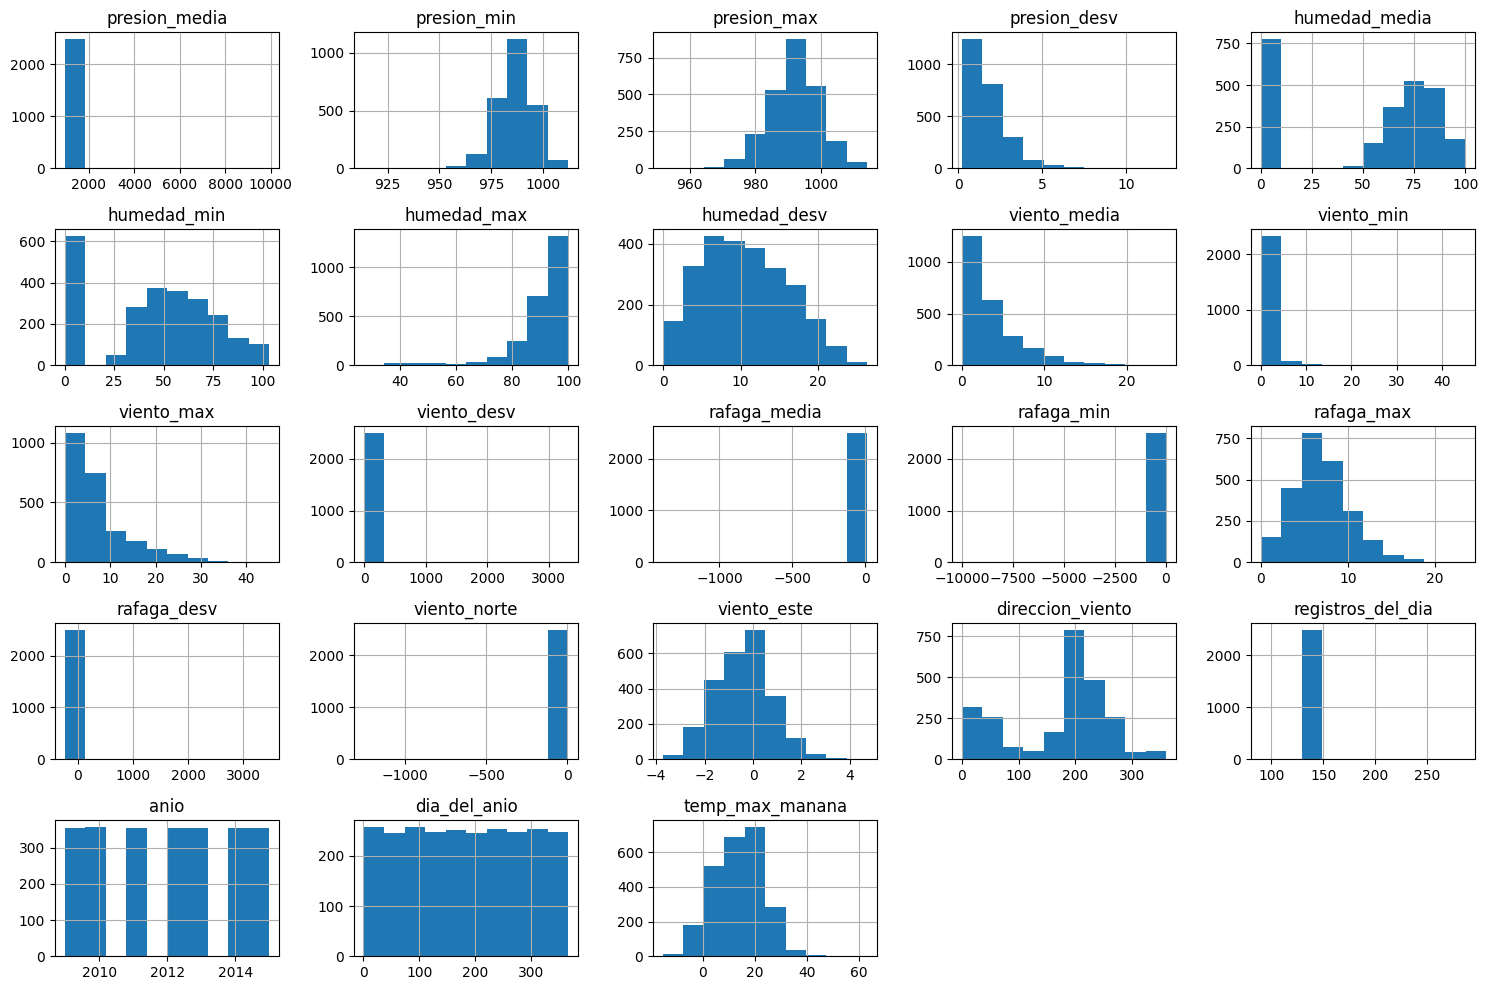

In [23]:
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

Análisis de las distribuciones: Los histogramas muestran que las variables meteorológicas presentan comportamientos distintos. Algunas variables, como `viento_media`, `viento_max` y `rafaga_max`, presentan distribuciones asimétricas con colas hacia valores altos, mientras que otras se encuentran más concentradas en rangos específicos.<br><br>
También se identifican posibles valores extremos en variables como `presion_desv`, `rafaga_desv` y `viento_norte`, que deberán ser analizados antes de determinar si corresponden a observaciones válidas o anomalía. <br><br>
Por su lado, variables como `presion_min`, `presion_max` y `temp_max_manana` (nuestra variable objetivo) muestran distribuciones aproximadamente normales centradas en rangos físicamente coherentes.

En un análisis más profundo de nuestra variable objetivo `temp_max_manana`, realizaremos un boxplot que nos permitirá visualizar los outliers registrados, los cuales contabilizaremos y reportaremos su porcentaje relativo. Esto con la intención de entender la distribución de la variable y cómo esta impacta el modelo de regresión lineal que vamos a desarrollar.

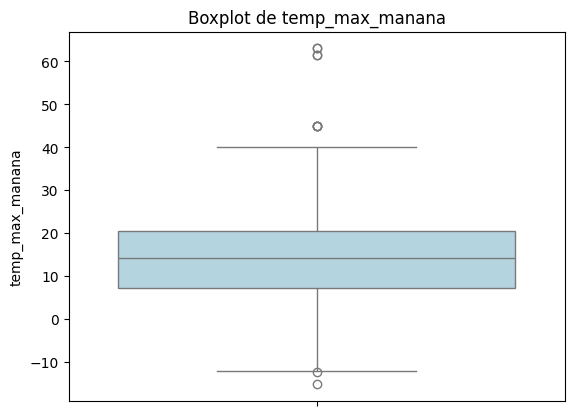

IQR: 13.15
Límite inferior: -12.42
Límite superior: 40.19
Cantidad de outliers: 10
Porcentaje relativo de outliers: 0.40%


In [24]:
sns.boxplot(data=data, y=data['temp_max_manana'], color='lightblue')
plt.title('Boxplot de temp_max_manana')
plt.show()

Q1 = data['temp_max_manana'].quantile(0.25)
Q3 = data['temp_max_manana'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = data[(data['temp_max_manana'] < limite_inferior) | (data['temp_max_manana'] > limite_superior)]
num_outliers = len(outliers)
total_validos = data['temp_max_manana'].count()
porcentaje_outliers = (num_outliers / total_validos) * 100

print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Cantidad de outliers: {num_outliers}")
print(f"Porcentaje relativo de outliers: {porcentaje_outliers:.2f}%")

El análisis mediante el método del Rango Intercuartílico (IQR) identificó únicamente 10 valores atípicos en la variable objetivo, lo que representa aproximadamente un 0.4% del total de datos válidos.Este resultado es altamente positivo para la fase de modelado predictivo por las siguientes razones:
- Alta estabilidad y calidad de la variable: La baja presencia de outliers confirma que la distribución de la temperatura máxima de la mañana es continua, coherente y prácticamente libre de errores.
- Menor sesgo en métricas de evaluación: Las métricas de error cuadrático habituales en regresión (como RMSE o R^2) son altamente sensibles a valores extremos. Al contar con un porcentaje tan marginal de datos atípicos, el modelo no sufrirá penalizaciones artificiales ni sesgos severos durante la fase de entrenamiento y validación.
- Preservación de la muestra: Al ser tan solo 10 registros, es posible aislarlos, imputarlos o eliminar de manera segura estos días atípicos sin perder representatividad ni volumen de datos en el conjunto de entrenamiento.

### 3.6 Correlaciones entre las variables
A través de un mapa de calor analizaremos la correlación que existe entre las distintas variables numéricas del conjunto de datos. Esto nos ayudará a identificar tanto las variables que más correlación tienen con la variable objetivo así como a detectar posibles problemas de colinealidad entre las variables explicativas candidatas.

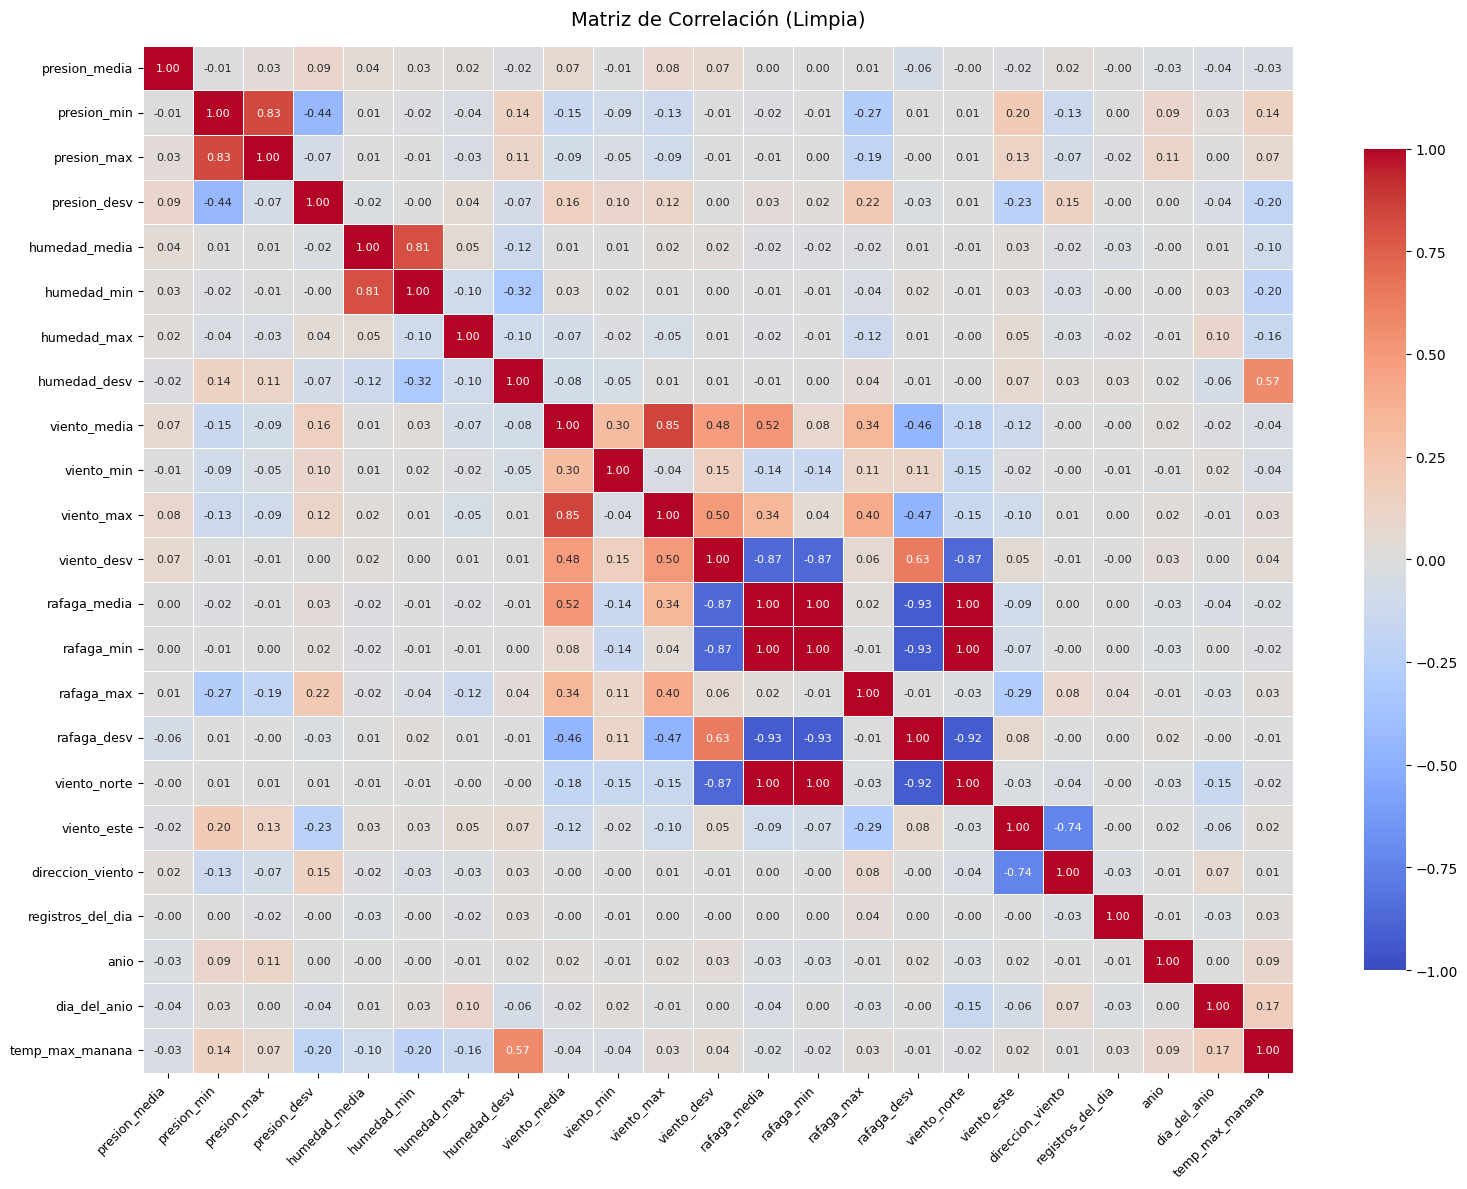

In [25]:
data_numbers = data.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
sns.heatmap(
    data_numbers.corr(), 
    annot=True, 
    fmt=".2f",                 
    cmap="coolwarm",            
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    annot_kws={"size": 8},    
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlación (Limpia)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

Con el mapa de calor nos podemos dar cuenta que la variable que más se correlaciona con la objetivo es `humedad_desv`, es decir, la desviación en la métrica de la humedad es lo que más se correlaciona con la temperatura máxima registrada al día siguiente. El resto de variables numéricas tienen una correlación con la variable objetivo que tiende a 0. <br><br>
Adicionalmente, este mapa pone en evidencia algo intuitivo: las variables que responden a métricas metereológicas están muy correlacionadas entre sí, por ejemplo, entre `viento_desv` y `viento_max`. Es decir, la colinealidad entre este tipo de variables es un factor a considerar en el diseño del modelo.

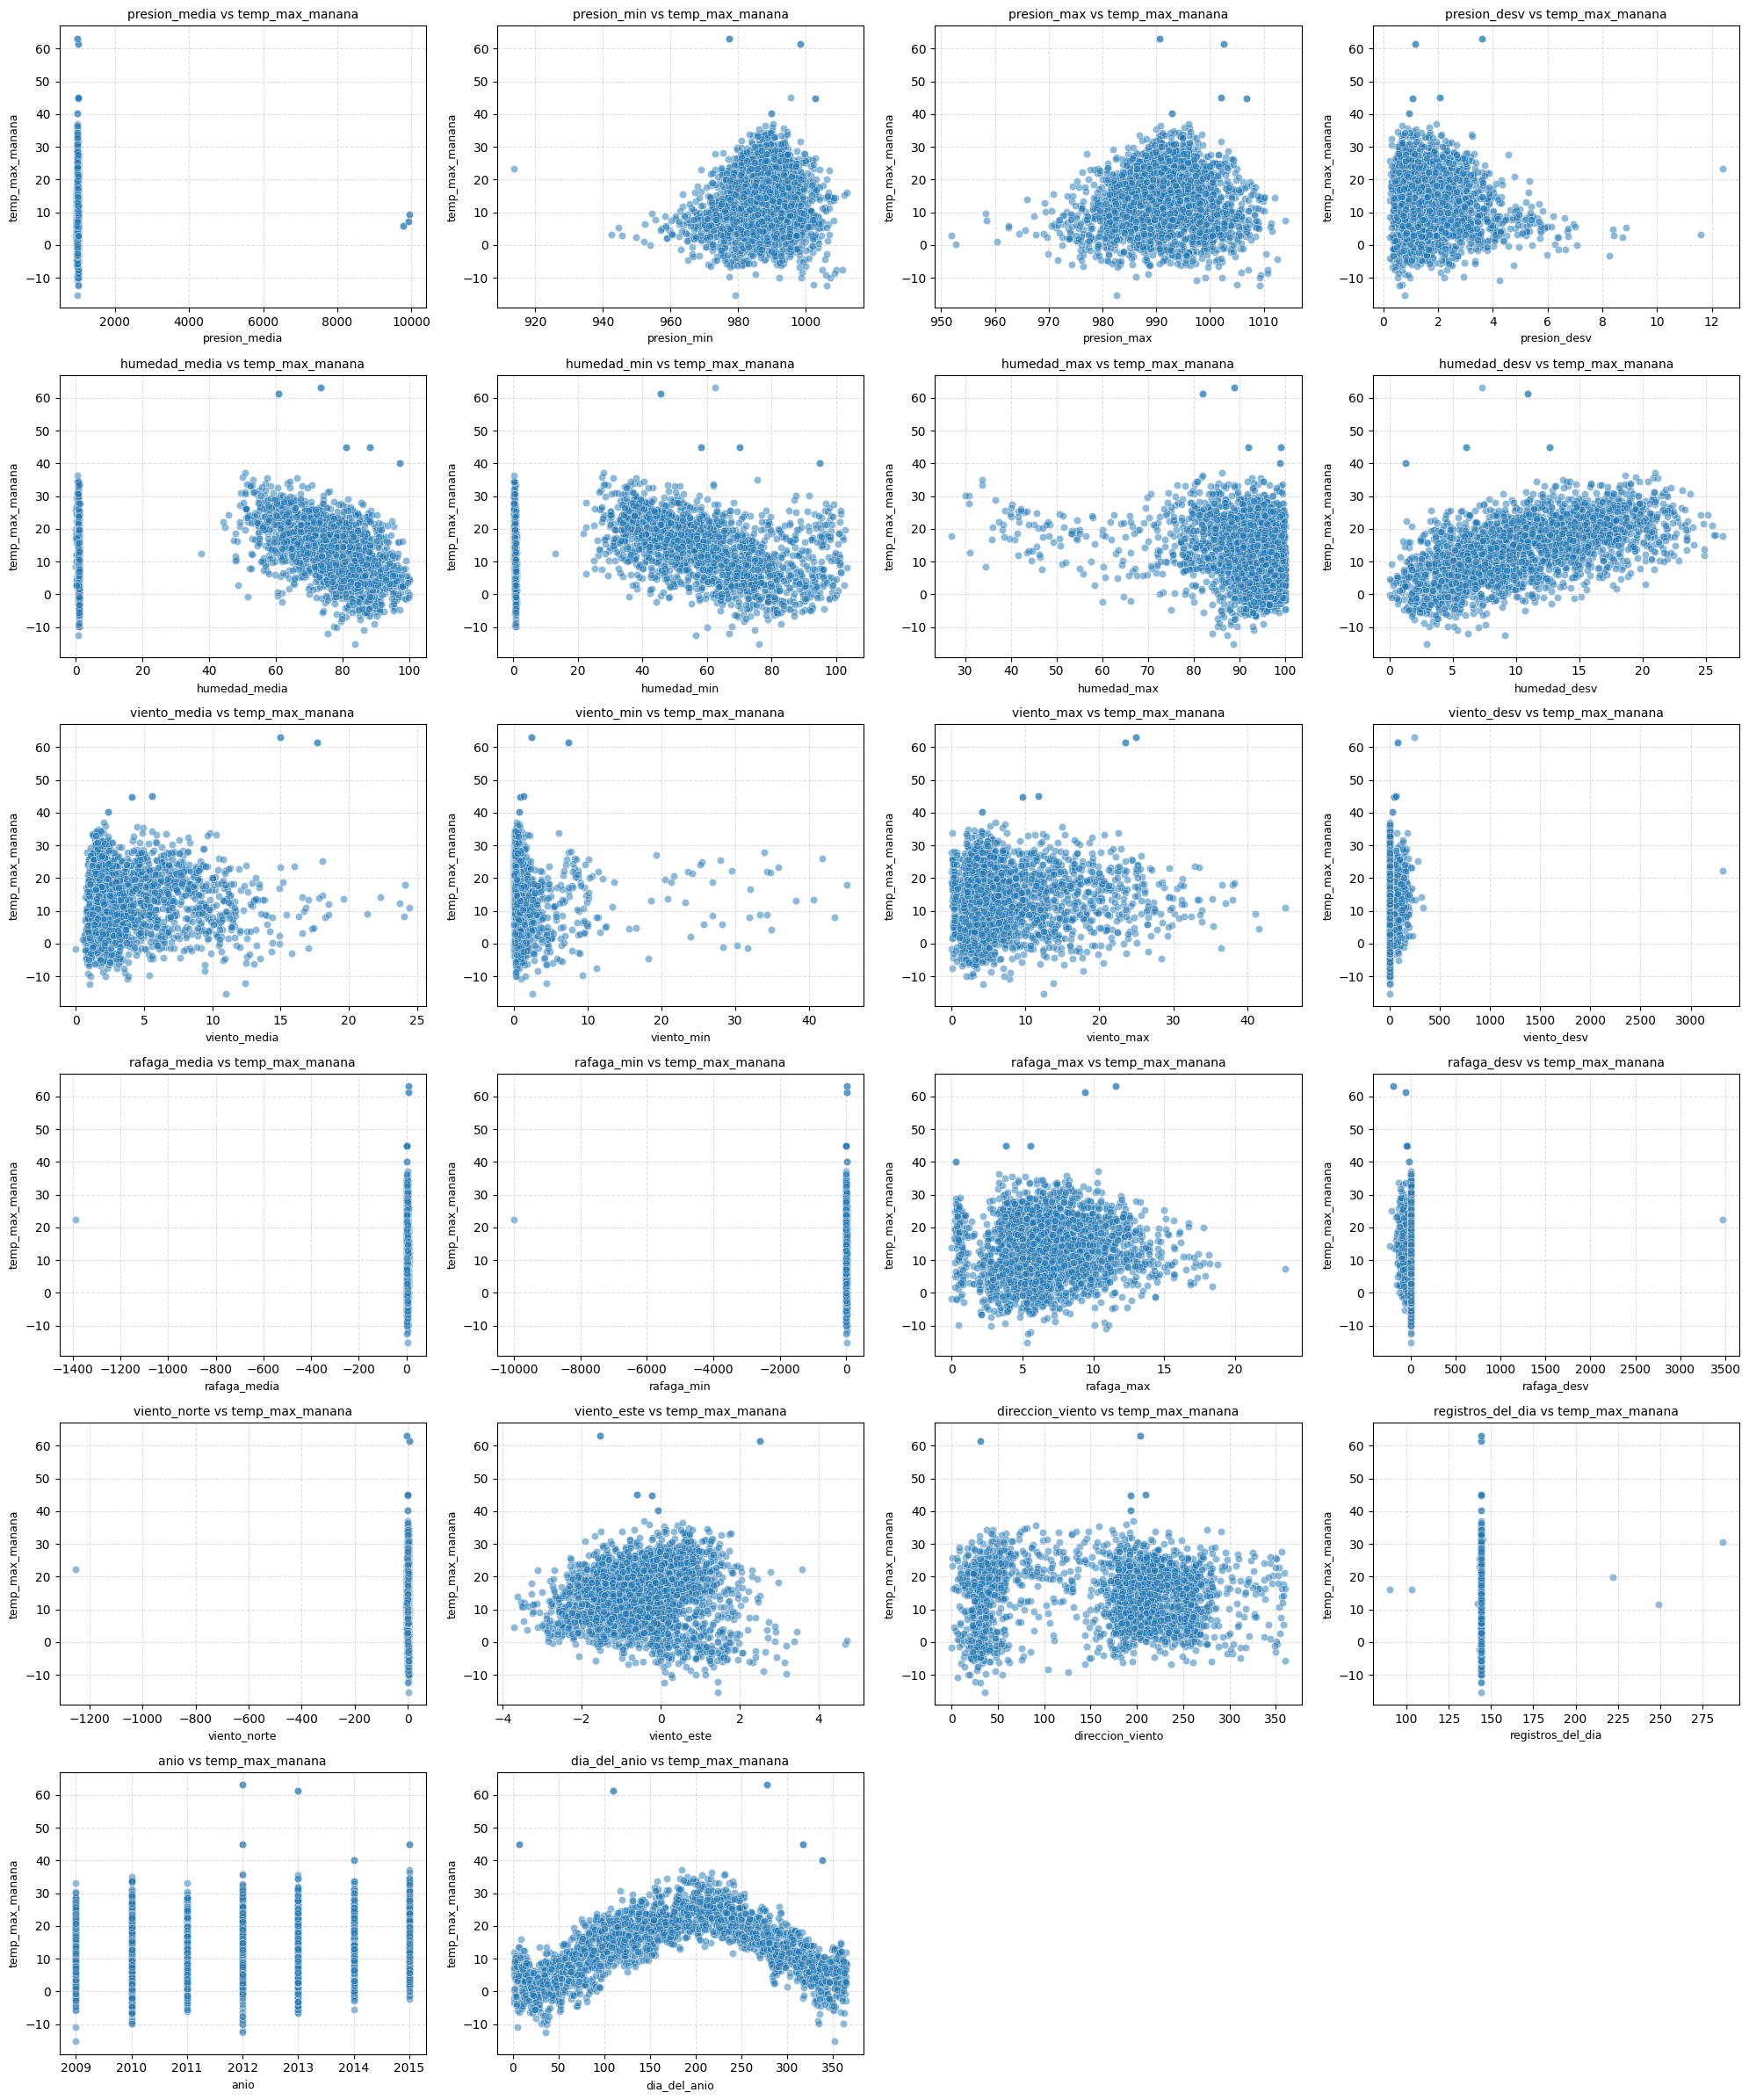

In [26]:
import math

cols_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
if 'temp_max_manana' in cols_numericas:
    cols_numericas.remove('temp_max_manana')

num_vars = len(cols_numericas)
cols_grid = 4
filas_grid = math.ceil(num_vars / cols_grid)

fig, axes = plt.subplots(filas_grid, cols_grid, figsize=(20, 4 * filas_grid))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.scatterplot(
        data=data, 
        x=col, 
        y='temp_max_manana', 
        ax=axes[i], 
        alpha=0.5,
        color='tab:blue'
    )
    axes[i].set_title(f'{col} vs temp_max_manana', fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('temp_max_manana', fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Estos diagramas de dispersión sirven como otra herramienta visual que corrobora las conclusiones definidas previamente en esta misma sección. Además, pone en evidencia algo que llamó la atención del equipo de trabajo: **la relación entre `dial_del_anio` y `temp_max_manana`**, pues no se trata de una relación lineal, pero sí refleja un patrón acorde a la realidad y las estaciones del año. Con ayuda de IAG (Gemini), entendimos que es una variable con naturaleza cíclica y se vería benificiada de ser descompuesta en seno y coseno. Al aplicar esta transofrmación seríamos capaces de proyectar la continuidad del año (y las estaciones), la misma lógica pudo ser transpuesta a la dirección del viento.

### 3.7 Análisis de los 4 principios de calidad de los datos
Dada la exploración previa de los datos, esta sección se propone sintetizar los datos recabados en los 4 principios de calidad de los datos, explicando hasta qué punto el DataFrame entregado por AlpesPLanck los respeta.

#### 3.7.1 Unicidad 
Se detectaron 4 filas completamente duplicadas e inconsistencias en la variable temporal con 89 fechas repetidas, lo que requiere una depuración de registros para no alterar las métricas de entrenamiento.

#### 3.7.2 Completitud
El dataset presenta una pérdida moderada de información (entre el 2.37% y 3.69% de valores nulos por columna). La variable objetivo (temp_max_manana) registra 95 valores faltantes (3.69%), los cuales pueden imputarse mediante técnicas para series temporales o filtrarse sin comprometer significativamente el volumen de datos.

#### 3.7.3 Consistencia
Existen severas contradicciones de formato y categorización. Se observan mezclas de idiomas y formatos en las variables de mes y estacion_anio (ej. January, Enero, JULY, East), además de picos anómalos de registros agrupados en $0\%$ para la humedad.

In [27]:
cols_object = data.select_dtypes(include=['object']).columns

print("=== CONTEO DE INCONSISTENCIAS EN VARIABLES CATEGÓRICAS ===\n")

for col in cols_object:
    print(f"--- Variable: {col} ---")
    conteo = data[col].value_counts(dropna=False)
    print(conteo)
    print(f"Total de categorías distintas: {data[col].nunique(dropna=False)}")
    print("-" * 40)

=== CONTEO DE INCONSISTENCIAS EN VARIABLES CATEGÓRICAS ===

--- Variable: fecha ---
fecha
NaN           72
2010-10-25     2
2009-05-02     2
2015-12-07     2
2009-03-05     2
              ..
2011-05-03     1
2011-05-04     1
2011-05-05     1
2011-05-06     1
2014-12-05     1
Name: count, Length: 2487, dtype: int64
Total de categorías distintas: 2487
----------------------------------------
--- Variable: estacion_anio ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10


#### 3.7.4 Validez
Se identificaron valores fuera de rango físico real y códigos de error no procesados. Destacan valores centinela (como -9999 en rafaga_min), presiones imposibles (> 9000 mbar) y humedades superiores al 100%. Estos datos anómales distorsionan los histogramas y comprometen la integridad del modelo que se busca realizar.

**Conclusión:** Aunque la variable objetivo (`temp_max_manana`) muestra un comportamiento muy estable con solo 10 outliers reales (0.4%), el conjunto de datos general requiere una fase rigurosa de limpieza (remoción de duplicados, reemplazo de valores centinelas y estandarización y normalización de las variables numéricas) antes de avanzar hacia la selección de características y el modelado predictivo a través de la regresión lineal.

Se divide el DataFrame inicial, extraído de 'Datos Lab 1.csv' en dos prociones: uno de entrenamiento para entrenar los modelos que se van a diseñar y otro de prueba para comprobar su desempeño.

### 4. Preparación de los datos (teórico)
Esta sección se encargará de plantear cuáles fueron los aspectos problemáticos que se encontraron en el conjunto de datos provisto por el equipo de AlpesPlanck y formular las respectivas decisiones que, consideramos, mejorarían la calidad de los datos y, por tanto, los modelos de regresión lineal a construir. <br><br>
**Nota:** Este apartado va a ser netamente expositivo/teórico, las operaciones de imputación, eliminación, estandarización y transfromación aquí planteados se llevará a cabo en secciones posteriores destinadas a la construcciones de las pipelines y los modelos. 

#### 4.1 Problemas identificados
1. **Duplicidad e inconsistencias temporales**
- 89 fechas aparecen repetidas con valores diferentes.
- 4 registros son completamente idénticos.
2. **Valores anómalos o inválidos**
- Presiones extremadamente altas/bajas.
- Humedad relativa superior al 100%.
- Valores negativos en variables que representan magnitudes no negativas.
- Desviaciones estándar negativas.
- Valores extremos en componentes del viento.
- `registros_del_dia` superiores al máximo esperado.
- Temperaturas máximas más altas de lo común.
- Valores centinela como -9999 (en `rafaga_min` por ejemplo).
- Valores inconsistentes en variables categóricas (mayúscula/minúscula, español/inglés)
3. **Valores faltantes**
- Existen valores ausentes en diferentes variables explicativas.
- También existen valores ausentes en la variable objetivo.
4. **Problemas de consistencia entre variables**

Debe comprobarse por registro que se cumplan relaciones como:

$$ min \leq media \leq max $$

para las variables meteorológicas.

5. **Tipos de datos**
- Variables object requieren revisión.
- Las fechas deberían convertirse a un formato temporal.
- Las variables categóricas, si son utilizadas, requieren una estrategia de codificación.
6. **Posible multicolinealidad**
- Algunas variables meteorológicas presentan correlaciones elevadas.
- Las variables min, media y max de una misma magnitud pueden estar fuertemente relacionadas. Se debe analizar el efecto de esta relación sobre la regresión.
7. **Variables con naturaleza cíclica**
- direccion_viento
- dia_del_anio
<br>Estas podrían requerir ingeniería de características para representar correctamente su naturaleza.

#### 4.2 Plan de procesamiento de datos
Cabe aclarar que aquí plasmamos todas las estrategias que se le ocurrieron al equipo de trabajo que escribe el presente. Sin embargo, como se busca crear dos modelos que comparar, existirá uno que implementará todo lo aquí mencionado mientras que el procesamiento mínimo para modelar una regresión lineal coherentemente.

1. **Depuración de duplicados**
- Eliminación de redundancias: Aplicación de `drop_duplicates()` para remover los 4 registros completamente idénticos.
- Resolución de conflictos en fechas: Para las 89 fechas repetidas con mediciones diferentes, se conservaára el registro más completo para consolidar una única observación por día.
2. **Tratamiento de valores anómalos, centinelas e incoherencias**
- Sustitución de valores centinela por `NaN`: Reemplazo sistemático de códigos de error (ej. -9999.0 en `rafaga_min` y valores > 1100 mbar en presion_media) por valores faltantes (`NaN`) para evitar la distorsión de estadísticas.
- Acotamiento de variables por límites físicos (Clipping):
    - Se aplicará un límite superior de 100% a la `humedad_min` y `humedad_max`.
    - Se corregirán las desviaciones estándar negativas y valores fuera de dominio en las variables de viento.
    - Para la variable `registros_del_dia`, se ajustarán las observaciones que superen el máximo físico de 144 registros diarios
    
- Normalización categórica:
    - Estandarización a formato minúscula y eliminación de espacios en blanco.
    - Homogeneización del idioma y nombres de meses/estaciones mediante diccionarios de mapeo (ej. traducir 'January' y 'JULY' a 'Enero' y 'Julio').
    - Reemplazo de etiquetas inconsistentes (ej. convertir 'East' en la variable estacion_anio a NaN).
3. **Gestión de datos faltantes**
- Depuración en la variable objetivo (`temp_max_manana`): Eliminación directa de las 95 filas con la variable dependiente nula (`dropna(subset=['temp_max_manana'])`), garantizando que la evaluación del modelo se realice exclusivamente sobre mediciones reales.
- Imputación en variables explicativas:
    - Imputación por mediana: Cálculo de la mediana sobre el conjunto de entrenamiento (train) para imputar registros faltantes en variables numéricas sin producir Data Leakage.
4. **Validación de la consistencia inter-variable**
- Revisa registro por registro que se cumpla estrictamente el orden lógico:
$$ min \leq media \leq max $$
En los casos donde se identifique una inversión de valores en la igualdad, se marcarán ambos valores como NaN para su posterior imputación o eliminación. <br> <br>
5. **Adecuación de tipos y codificación de variables**
- Conversión temporal: Transformación de la columna fecha al tipo de dato datetime64[ns] y ordenamiento cronológico del dataset.
- Codificación de variables categóricas:Aplicación de One-Hot Encoding sobre variables nominales sin orden explícito (como `sector_viento` o `estacion_anio`).
6. **Tratamiento de multicolinealidad**
- Selección de características: Basado en la matriz de correlación, se determinarán las variables que pertenecen a una misma métrica meterológixa y se evaluará conservar únicamente media, previniendo la inestabilidad en los coeficientes de regresión.
7. **Ingeniería de características para variables cíclicas**
- Transformación de variables periódicas (`dia_del_anio` y `direccion_viento`) mediante sus componentes ortogonales trigonométricas seno y coseno:
$$\text{dia}_{\sin} = \sin\left(\frac{2\pi \cdot \text{día}}{365.25}\right), \quad \text{dia}_{\cos} = \cos\left(\frac{2\pi \cdot \text{día}}{365.25}\right)$$
$$\text{viento}_{\sin} = \sin\left(\frac{2\pi \cdot \text{dirección}}{360}\right), \quad \text{viento}_{\cos} = \cos\left(\frac{2\pi \cdot \text{dirección}}{360}\right)$$
Esto permitirá mapear la continuidad entre el inicio y fin de cada ciclo de forma suave y sin discontinuidades numéricas. <br>
8. **Escalado de Características** 
- Aplicación de StandardScaler sobre las variables explicativas continuas: Se utilizará estandarización para llevar las variables numéricas a una escala comparable y facilitar la interpretación relativa de los coeficientes.

### 5. Modelo 1: Procesamiento mínimo
Para este primer modelo se busca establecer una línea de base de rendimiento utilizando únicamente las transformaciones indispensables para que el algoritmo pueda ejecutarse sin errores técnicos, sin aplicar ingeniería de características ni imputaciones complejas.

A continuación, expondremos una por una las decisiones de procesamiento de datos que se van a incluir dentro de este primer modelo junto con su respectivo código funcional

1. **Tratamiento de registros y fechas duplicadas:**
Para dar cumplimiento al principio de unicidad de los datos, eliminaremos los 4 registros idénticos identificados previamente y manejaremos los 89 registros que presentan fechas duplicadas conservando aquel registro que tenga menor npumero de variables con valor `NaaN` 

In [28]:
# Manejamos copia de los datos (data) para proteger los datos en su estado  original
df_base = data.copy()
len_inicial = len(df_base)

# Eliminar duplicados exactos
df_base = df_base.drop_duplicates()
duplicados_exactos = len_inicial - len(df_base)

# Manejar fechas duplicadas: Conservar la que tenga MENOS valores NaN
# 1. Contamos cuántos NaN tiene cada fila
df_base['num_nans'] = df_base.isnull().sum(axis=1)

# 2. Ordenamos por fecha y por número de nulos (de menor a mayor)
df_base = df_base.sort_values(by=['fecha', 'num_nans'])
len_pre_fechas = len(df_base)

# 3. Borramos las fechas duplicadas quedándonos con la primera (la de menos NaN)
df_base = df_base.drop_duplicates(subset=['fecha'], keep='first')

# 4. Limpiamos la columna auxiliar
df_base = df_base.drop(columns=['num_nans'])
fechas_duplicadas_removidas = len_pre_fechas - len(df_base)

In [29]:
print(f"--- EVIDENCIA DE UNICIDAD ---")
print(f"Registros iniciales: {len_inicial}")
print(f"Duplicados exactos eliminados: {duplicados_exactos}")
print(f"Fechas duplicadas eliminadas (conservando el registro con menos NaN): {fechas_duplicadas_removidas}")
print(f"Total de registros limpios y únicos por fecha: {len(df_base)}")
print(f"¿Existe alguna fecha repetida en el dataset?: {df_base['fecha'].duplicated().any()}")

--- EVIDENCIA DE UNICIDAD ---
Registros iniciales: 2576
Duplicados exactos eliminados: 4
Fechas duplicadas eliminadas (conservando el registro con menos NaN): 85
Total de registros limpios y únicos por fecha: 2487
¿Existe alguna fecha repetida en el dataset?: False


2. **Eliminar registros con `temp_max_manana` nula:**
Aquellos registros en los que nuestra variable objetivo no tiene un valor registrado no nos interesan, pues no añden ningún valor a nuestro modelo predictivo. El aprendizaje supervisado implica que tiene que haber una etiqueta.

In [30]:
# Filtrar filas donde la variable objetivo es nula
df_base = df_base.dropna(subset=['temp_max_manana'])
catn_nulls_temp = df_base['temp_max_manana'].isna().sum()
print(f'Cantidad de registros con temp_max_manana es NaaN: {catn_nulls_temp}')

Cantidad de registros con temp_max_manana es NaaN: 0


3. **Tratamiento de valores anómalos y centinelas:**
Se aplicarán las pautas expuestas en la sección anterior para el manejo de valores registrados que son físicamente imposibles o improbables (estos se determinaron a partir de búsquedas en la web sobre los valores estándar de las variables metereológicas expuestas en el caso)

Técnicas usadas:
- Sustitución por NaN en lugar de imputar por el mínimo o cero: Reemplazar un error de lectura (como -9999 o 9939 mbar) por el valor mínimo inyecta un sesgo cuantitativo destructivo, haciendo creer al algoritmo que esos días hubo viento nulo o presión de tormenta extrema. Asignar NaN reconoce explícitamente la incertidumbre del dato.
- Filtros por dominio físico real vs. Umbrales globales: Se aplican intervalos validados por la física meteorológica (ej. presión entre 940 y 1040 mbar, desviación estándar $\ge 0$, etc.) en lugar de filtros globales arbitrarios (como < -500), asegurando no eliminar datos válidos ni dejar pasar errores sutiles.
- Acotamiento (Clipping) en Humedad y Registros: La humedad no puede superar el 100% ni el número de lecturas por día exceder 144. En lugar de descartar todo el día por un exceso menor de lectura, se acota la cota superior al máximo físico posible.

In [31]:
# Presión atmosférica (Dominio real ~940 a 1040 mbar)
cols_presion = [c for c in df_base.columns if 'presion' in c and 'desv' not in c and 'std' not in c]
for col in cols_presion:
    df_base.loc[(df_base[col] < 940) | (df_base[col] > 1040), col] = np.nan

# Humedad relativa (Clipping al 100% y depuración de 0s artificiales)
cols_humedad = [c for c in df_base.columns if 'humedad' in c]
for col in cols_humedad:
    df_base.loc[df_base[col] > 100, col] = 100.0
    df_base.loc[df_base[col] <= 0.05, col] = np.nan

# Viento, Ráfagas y Desviaciones Estándar
cols_viento_rafaga = [c for c in df_base.columns if 'viento' in c or 'rafaga' in c]
for col in cols_viento_rafaga:
    if 'desv' in col:
        df_base.loc[df_base[col] < 0, col] = np.nan
    if 'media' in col or 'min' in col or 'max' in col:
        df_base.loc[df_base[col] < 0, col] = np.nan

df_base.loc[df_base['viento_desv'] > 100, 'viento_desv'] = np.nan
df_base.loc[df_base['viento_norte'] < -100, 'viento_norte'] = np.nan

# Registros del día (Máximo 144 mediciones por día)
if 'registros_del_dia' in df_base.columns:
    df_base.loc[df_base['registros_del_dia'] > 144, 'registros_del_dia'] = 144

# Depuración de la Variable Objetivo
df_base.loc[df_base['temp_max_manana'] > 50.0, 'temp_max_manana'] = np.nan
df_base = df_base.dropna(subset=['temp_max_manana'])

In [32]:
print(f"--- EVIDENCIA DEL TRATAMIENTO A VALORES ANÓMALOS ---")
print(f"Mínimo en 'rafaga_min' (Antes: -9999): {df_base['rafaga_min'].min()}")
print(f"Máximo en 'presion_media' (Antes: ~9939): {df_base['presion_media'].max()} hPa")
print(f"Máximo en 'humedad_min' (Antes: 103.3%): {df_base['humedad_min'].max()}%")
print(f"Mínimo en 'viento_desv' (Antes: < 0): {df_base['viento_desv'].min()}")
print(f"Máximo en 'registros_del_dia' (Antes: 287): {df_base['registros_del_dia'].max()}")

--- EVIDENCIA DEL TRATAMIENTO A VALORES ANÓMALOS ---
Mínimo en 'rafaga_min' (Antes: -9999): 0.0
Máximo en 'presion_media' (Antes: ~9939): 1011.6538 hPa
Máximo en 'humedad_min' (Antes: 103.3%): 100.0%
Mínimo en 'viento_desv' (Antes: < 0): 0.0
Máximo en 'registros_del_dia' (Antes: 287): 144.0


4. **Estandariación de las variables categóricas:**
Corregir la falta de consistencia de texto (mezclas de inglés/español, mayúsculas/minúsculas y caracteres espurios) antes de entrar al codificador para evitar que una misma categoría (ej. 'Enero', 'january', 'JANUARY') se interprete como 3 variables distintas en One-Hot Encoding.
También aprovechamos para dropear la columna `fecha`, la cual se vuelve redundante para el modelo al ya contar con las columnas `anio`, `mes`, `dia_del_anio` 

In [33]:
# Eliminar la columna 'fecha' por redundancia con dia, mes y anio
if 'fecha' in df_base.columns:
    df_base = df_base.drop(columns=['fecha'])

# Normalización de las variables categóricas
cat_cols = df_base.select_dtypes(include=['object']).columns

for col in cat_cols:
    # Preservar nulos reales antes de convertir a string
    mask_nulls = df_base[col].isnull()
    
    # Estandarización básica: minúsculas y sin espacios extremos
    df_base[col] = df_base[col].astype(str).str.lower().str.strip()
    
    # Mapeo de meses
    if col == 'mes':
        mapeo_meses = {
            'january': 'enero', 'february': 'febrero', 'march': 'marzo',
            'april': 'abril', 'may': 'mayo', 'june': 'junio',
            'july': 'julio', 'august': 'agosto', 'september': 'septiembre',
            'october': 'octubre', 'november': 'noviembre', 'december': 'diciembre'
        }
        df_base[col] = df_base[col].replace(mapeo_meses)
        
    # Mapeo completo de estaciones del año
    if col == 'estacion_anio':
        mapeo_estaciones = {
            # Verano
            'summer': 'verano', 'verano': 'verano', 'berano': 'verano', 'verno': 'verano',
            # Invierno
            'winter': 'invierno', 'invierno': 'invierno', 'invernio': 'invierno',
            # Primavera
            'spring': 'primavera', 'primavera': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera',
            # Otoño
            'autumn': 'otoño', 'fall': 'otoño', 'otoño': 'otoño', 'otono': 'otoño'
        }
        df_base[col] = df_base[col].replace(mapeo_estaciones)
        
        # Reemplazar valores ambivalentes/inválidos directamente por NaN
        valores_invalidos = ['inverano', 'estacion_desconocida', 'verano_invierno', 'east']
        df_base[col] = df_base[col].replace(valores_invalidos, np.nan)
        
    # Mapeo explícito para sector_viento
    if col == 'sector_viento':
        mapeo_viento = {
            'southwest': 'so', 'suroeste': 'so', 'sw': 'so',
            'northwest': 'no', 'noroeste': 'no', 'nw': 'no',
            'southeast': 'se', 'sudeste': 'se', 'sureste': 'se',
            'northeast': 'ne', 'noreste': 'ne',
            'south': 's', 'sur': 's',
            'north': 'n', 'norte': 'n',
            'east': 'e', 'este': 'e',
            'west': 'o', 'oeste': 'o'
        }
        df_base[col] = df_base[col].replace(mapeo_viento)

    # Re-asignar NaN reales a lo que era originalmente nulo o texto 'nan' / 'none'
    df_base.loc[mask_nulls | df_base[col].isin(['nan', 'none', '']), col] = np.nan

In [34]:
print("--- EVIDENCIA DE ESTANDARIZACIÓN DE LAS VARIABLES CATEGÓRICAS ---")
print(f"¿Columna 'fecha' sigue en el DataFrame?: {'fecha' in df_base.columns}")
print("\nCategorías unificadas en 'sector_viento':")
print(df_base['sector_viento'].value_counts(dropna=False))

print("\nCategorías unificadas en 'mes' (Primeras 5):")
print(df_base['mes'].value_counts(dropna=False).head(5))

print("\nCategorías unificadas en 'estacion_anio':")
print(df_base['estacion_anio'].value_counts(dropna=False))

--- EVIDENCIA DE ESTANDARIZACIÓN DE LAS VARIABLES CATEGÓRICAS ---
¿Columna 'fecha' sigue en el DataFrame?: False

Categorías unificadas en 'sector_viento':
sector_viento
so     717
s      538
ne     442
o      306
n      132
e       75
se      68
NaN     63
no      51
Name: count, dtype: int64

Categorías unificadas en 'mes' (Primeras 5):
mes
enero        198
mayo         188
marzo        183
julio        179
diciembre    175
Name: count, dtype: int64

Categorías unificadas en 'estacion_anio':
estacion_anio
primavera    537
invierno     529
otoño        518
verano       503
NaN          305
Name: count, dtype: int64


5. **Pipeline final:**
Ensamblaje con pipeline (scikit-learn)

In [35]:
# Separación de conjuntos (X, y)
X = df_base.drop(columns=['temp_max_manana'])
y = df_base['temp_max_manana']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Columnas numéricas continuas consideradas para este modelo: {num_cols}')
print(f'Columnas categóricas consideradas para este modelo:  {cat_cols}')

Columnas numéricas continuas consideradas para este modelo: ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio']
Columnas categóricas consideradas para este modelo:  ['estacion_anio', 'mes', 'sector_viento']


In [36]:
# Split (Siguiendo indicaciones del lab)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

**Sub-pipeline de Variables Numéricas (`num_pipeline`):**
* **SimpleImputer(strategy='median'):** Imputa los valores faltantes (`NaN`) reemplazándolos por la **mediana** de cada variable cuantitativa. Se prefiere la mediana sobre la media en el modelo baseline debido a su robustez frente a valores atípicos presentes en las mediciones meteorológicas.

In [37]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

**Sub-pipeline de Variables Categóricas (`cat_pipeline`):**
* **SimpleImputer(strategy='most_frequent'):** Completa los datos nulos sustituyéndolos por la **moda** (el valor categórico que se repite con mayor frecuencia en el conjunto de datos de entrenamiento).
* **OneHotEncoder(handle_unknown='ignore', drop='first'):** Codifica las variables categóricas nominales en vectores binarios. 
  * `drop='first'`: Elimina la primera categoría para prevenir la **multicolinealidad perfecta**.
  * `handle_unknown='ignore'`: Evita errores durante la fase de prueba si el modelo encuentra una categoría no vista durante el entrenamiento.

In [38]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

**Ensamblador de Procesamiento (`preprocessor` / `ColumnTransformer`):**
* **ColumnTransformer:** Integra las transformaciones aplicando de forma independiente el `num_pipeline` a las columnas cuantitativas y el `cat_pipeline` a las cualitativas, garantizando que el tratamiento de tipos de datos sea aislado, ordenado e inmune a data leakage.

In [39]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

**Pipeline Global del Estimador (`baseline_pipeline`):**
* Encapsula todo el flujo de preparación de datos (`preprocessor`) secuencialmente con el algoritmo final (**LinearRegression**). Garantiza que los pasos de ajuste (`fit`) y transformación (`transform`) se ejecuten **únicamente sobre las muestras de entrenamiento**, previniendo la fuga de datos hacia el conjunto de prueba (`X_test`).

In [40]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


set_config(display="diagram")
baseline_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['presion_media',
                                                   'presion_min', 'presion_max',
                                                   'presion_desv',
                                                   'humedad_media',
                                                   'humedad_min', 'humedad_max',
                                                   'humedad_desv',
                                                   'viento_media', 'viento_min',
                                                   'viento_max', 'viento_desv',
                                                   'rafaga_media', 'rafaga_min',
                                                   'rafaga_max', 'rafaga_desv',
                                                   'viento_norte',
                                                   'viento_este',
                                                   'direccion_viento',
                                                   'registros_del_dia', 'anio',
                                                   'dia_del_anio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['estacion_anio', 'mes',
                                                   'sector_viento'])])),
                ('regressor', LinearRegression())])

In [41]:
# 4. Entrenamiento y Predicción
baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)

In [42]:
# 5. Métricas de evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [43]:
print("=== RESULTADOS Y EVIDENCIA FINAL DEL MODELO 1: BASELINE ===")
print(f"Dimensiones del set de entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones del set de prueba (X_test):        {X_test.shape}")
print("-" * 55)
print(f"RMSE (Error Cuadrático Medio): {rmse:.4f} °C")
print(f"MAE  (Error Absoluto Medio):    {mae:.4f} °C")
print(f"R²   (Coef. de Determinación): {r2:.4f}")

=== RESULTADOS Y EVIDENCIA FINAL DEL MODELO 1: BASELINE ===
Dimensiones del set de entrenamiento (X_train): (1794, 25)
Dimensiones del set de prueba (X_test):        (598, 25)
-------------------------------------------------------
RMSE (Error Cuadrático Medio): 6.3127 °C
MAE  (Error Absoluto Medio):    5.0057 °C
R²   (Coef. de Determinación): 0.4773


### 6. Modelo 2: optimizado
En esta sección se presenta el segundo modelo diseñado. Se busca que este parta de la misma base que el modelo anterior (por tanto usaremos una copia de df_base), pero aplicaremos ciertas mejoras con la intención de ver reflejada una mejoría en en las métricas estadísticas resultantes del modelo entrenado y su predicción.

In [44]:
# Copia de seguridad para trabajar el Modelo 2 sin alterar df_base
df_m2 = df_base.copy()

1. **Ingeniería de características cíclicas**

Las variables como el **día del año** ($1$ a $365.25$) y la **dirección del viento** ($0^\circ$ a $360^\circ$) son cíclicas por naturaleza. 

* En la dirección del viento, $0^\circ$ (Norte) y $359^\circ$ están físicamente contiguos, pero numéricamente distantes.
* En el calendario, el día 365 (fin de año) y el día 1 (inicio de año) son días consecutivos.

Para que el algoritmo interprete correctamente esta continuidad espacial y temporal, descomponemos cada variable en sus componentes ortogonales de **Seno** ($\sin$) y **Coseno** ($\cos$):

$$\text{dia}_{\sin} = \sin\left(\frac{2\pi \cdot \text{día}}{365.25}\right), \quad \text{dia}_{\cos} = \cos\left(\frac{2\pi \cdot \text{día}}{365.25}\right)$$

$$\text{viento}_{\sin} = \sin\left(\frac{2\pi \cdot \text{dirección}}{360}\right), \quad \text{viento}_{\cos} = \cos\left(\frac{2\pi \cdot \text{dirección}}{360}\right)$$

In [45]:
# 1. Transformación cíclica para el día del año (Período: 365.25)
col_dia = 'dia_del_anio'
df_m2['dia_sin'] = np.sin(2 * np.pi * df_m2[col_dia] / 365.25)
df_m2['dia_cos'] = np.cos(2 * np.pi * df_m2[col_dia] / 365.25)
df_m2 = df_m2.drop(columns=[col_dia])

# 2. Transformación cíclica para la dirección del viento (Período: 360°)
col_viento = 'direccion_viento'
df_m2['direccion_viento_sin'] = np.sin(2 * np.pi * df_m2[col_viento] / 360.0)
df_m2['direccion_viento_cos'] = np.cos(2 * np.pi * df_m2[col_viento] / 360.0)
df_m2 = df_m2.drop(columns=[col_viento])

--- EVIDENCIA DE TRANSFORMACIÓN CÍCLICA ---
Nuevas variables cíclicas generadas (4): ['dia_sin', 'dia_cos', 'direccion_viento_sin', 'direccion_viento_cos']


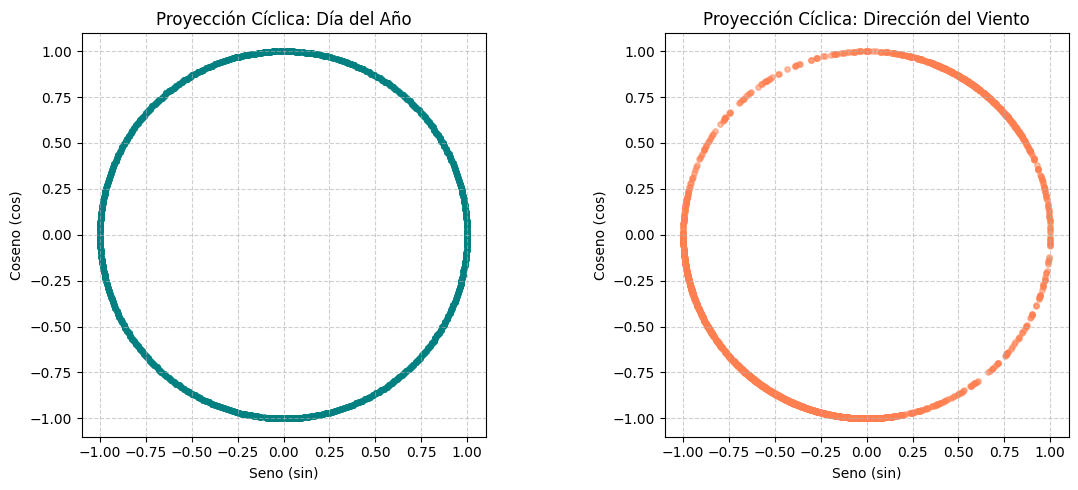


Verificación de límites numéricos [-1.0, 1.0]:
      dia_sin   dia_cos  direccion_viento_sin  direccion_viento_cos
min -0.999999 -0.999979             -1.000000                  -1.0
max  0.999986  0.999991              0.999976                   1.0


In [46]:
print("--- EVIDENCIA DE TRANSFORMACIÓN CÍCLICA ---")
# 1. Comprobación de existencia de nuevas columnas
cols_ciclicas = [c for c in df_m2.columns if '_sin' in c or '_cos' in c]
print(f"Nuevas variables cíclicas generadas ({len(cols_ciclicas)}): {cols_ciclicas}")

# 2. Generación de gráfico de circunferencia unitaria para validar la geometría
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para el Día del Año
if 'dia_sin' in df_m2.columns and 'dia_cos' in df_m2.columns:
    axes[0].scatter(df_m2['dia_sin'], df_m2['dia_cos'], alpha=0.5, color='teal', s=15)
    axes[0].set_title("Proyección Cíclica: Día del Año")
    axes[0].set_xlabel("Seno (sin)")
    axes[0].set_ylabel("Coseno (cos)")
    axes[0].set_aspect('equal')
    axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico para la Dirección del Viento
if 'direccion_viento_sin' in df_m2.columns and 'direccion_viento_cos' in df_m2.columns:
    axes[1].scatter(df_m2['direccion_viento_sin'], df_m2['direccion_viento_cos'], alpha=0.5, color='coral', s=15)
    axes[1].set_title("Proyección Cíclica: Dirección del Viento")
    axes[1].set_xlabel("Seno (sin)")
    axes[1].set_ylabel("Coseno (cos)")
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Resumen estadístico del rango [-1, 1]
print("\nVerificación de límites numéricos [-1.0, 1.0]:")
print(df_m2[cols_ciclicas].describe().loc[['min', 'max']])

2. **Detección y Eliminación de Colinealidad**

Para evitar que variables altamente redundantes desestabilicen los coeficientes del modelo lineal, generamos un mapa de calor. Eliminaremos de forma automática aquellas variables numéricas con una correlación absoluta elevada.

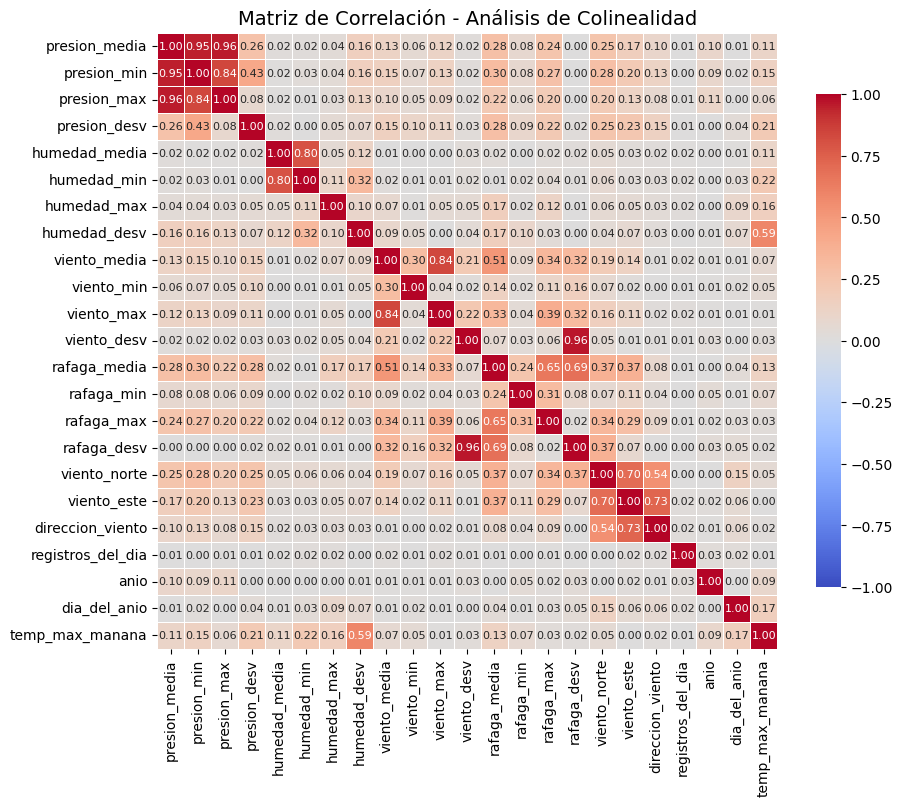

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas para el análisis de correlación
num_temp_df = df_base.select_dtypes(include=[np.number])
corr_matrix = num_temp_df.corr().abs()

# Graficar mapa de calor de colinealidad
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f",                 
    cmap="coolwarm",            
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    annot_kws={"size": 8},    
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de Correlación - Análisis de Colinealidad", fontsize=14)
plt.show()

##### Selección de Variables por Redundancia (r >= 0.80)

A partir del mapa de calor, se identificaron 5 variables redundantes con coeficientes de correlación lineal superiores a 0.80:
1. **`presion_min` y `presion_max`**: Altamente correlacionadas con `presion_media` ($r \ge 0.95$). Conservamos únicamente la media diaria.
2. **`humedad_min`**: Presenta una correlación de $0.80$ con `humedad_media`.
3. **`viento_max`**: Colineal con `viento_media` ($r = 0.84$).
4. **`rafaga_desv`**: Prácticamente idéntica a `viento_desv` ($r = 0.96$), reflejando el mismo fenómeno físico de dispersión de velocidad.

Su eliminación reduce la dimensionalidad sin perder información meteorológica clave y previene la inestabilidad en los coeficientes del modelo.

In [48]:
cols_a_eliminar = ['presion_min', 'presion_max', 'humedad_min', 'viento_max', 'rafaga_desv']

# Aplicar eliminación sobre df_m2
df_m2 = df_m2.drop(columns=cols_a_eliminar)

3. **Construccion del pipeline optimizado (Modelo 2):**
<br>El nuevo pipeline introduce: `StandardScaler()`, este estandariza las variables numéricas restando la media y dividiendo por la desviación estándar, permitiendo que el algoritmo aprenda con la misma escala. <br><br>
De resto, el pipeline se mantiene igual, pues las decisiones que se tomaron para mejorar el modelo fueron las explicadas recien.

In [49]:
# A. Separar características (X) y objetivo (y)
X = df_m2.drop(columns=['temp_max_manana'])
y = df_m2['temp_max_manana']

# Redefinir tipos de columnas tras la ingeniería de características
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Columnas numéricas continuas consideradas para este modelo: {num_cols}')
print(f'Columnas categóricas consideradas para este modelo: {cat_cols}')

Columnas numéricas continuas consideradas para este modelo: ['presion_media', 'presion_desv', 'humedad_media', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'dia_sin', 'dia_cos', 'direccion_viento_sin', 'direccion_viento_cos']
Columnas categóricas consideradas para este modelo: ['estacion_anio', 'mes', 'sector_viento']


In [50]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Sub-pipelines
num_pipeline_opt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

cat_pipeline_opt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Ensamblador
preprocessor_opt = ColumnTransformer(transformers=[
    ('num', num_pipeline_opt, num_cols),
    ('cat', cat_pipeline_opt, cat_cols)
])

# Pipeline Principal con Linear Regression
optimized_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_opt),
    ('regressor', LinearRegression()) 
])

set_config(display="diagram")
optimized_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['presion_media',
                                                   'presion_desv',
                                                   'humedad_media',
                                                   'humedad_max',
                                                   'humedad_desv',
                                                   'viento_media', 'viento_min',
                                                   'viento_desv',
                                                   'rafaga_media', 'rafaga_min',
                                                   'rafaga_max', 'viento_norte',
                                                   'viento_este',
                                                   'registros_del_dia', 'anio',
                                                   'dia_sin', 'dia_cos',
                                                   'direccion_viento_sin',
                                                   'direccion_viento_cos']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['estacion_anio', 'mes',
                                                   'sector_viento'])])),
                ('regressor', LinearRegression())])

In [51]:
# Entrenamiento y Predicción
optimized_pipeline.fit(X_train, y_train)
y_pred_opt = optimized_pipeline.predict(X_test)

# Cálculo de Métricas del Modelo 2
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
mae_opt = mean_absolute_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print("=== RESULTADOS MODELO 2: OPTIMIZADO ===")
print(f"RMSE: {rmse_opt:.4f} °C")
print(f"MAE:  {mae_opt:.4f} °C")
print(f"R²:   {r2_opt:.4f}")

=== RESULTADOS MODELO 2: OPTIMIZADO ===
RMSE: 4.7015 °C
MAE:  3.5896 °C
R²:   0.7101


### 7. Comparación de modelos

Ahora se consolida el desempeño de ambos modelos en una tabla comparativa evaluados sobre el mismo conjunto de prueba (`test_size=0.25`, `random_state=42`).

In [65]:
comparacion = pd.DataFrame({
    'Modelo': ['Modelo 1 (Baseline)', 'Modelo 2 (Optimizado)'],
    'RMSE (°C)': [rmse, rmse_opt],
    'MAE (°C)': [mae, mae_opt],
    'R²': [r2, r2_opt]
})
comparacion

,Modelo,RMSE (°C),MAE (°C),R²
0,Modelo 1 (Baseline),6.312685,5.005701,0.477330
1,Modelo 2 (Optimizado),4.701462,3.589605,0.710089


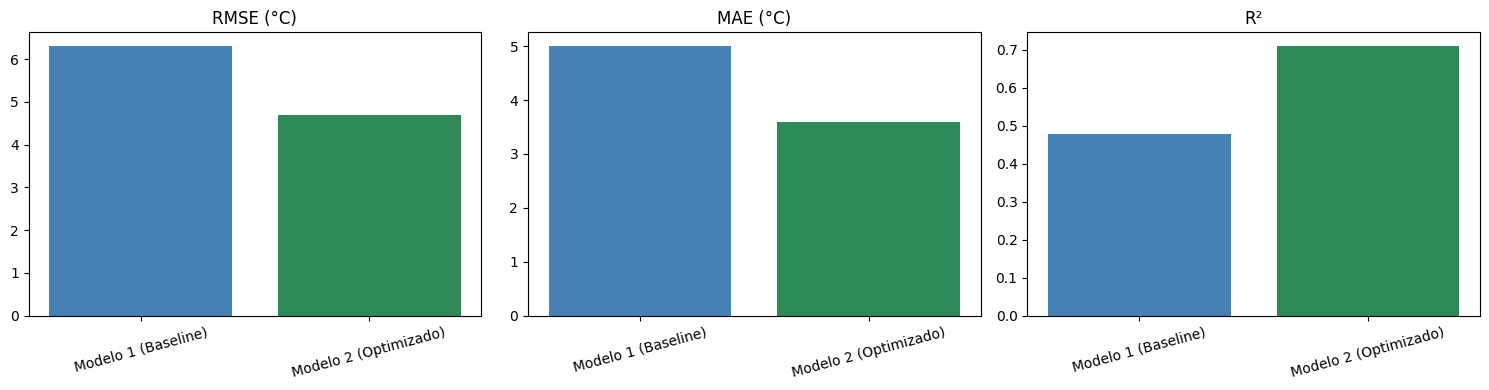

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
metricas = ['RMSE (°C)', 'MAE (°C)', 'R²']
colores = ['steelblue', 'seagreen']

for ax, metrica in zip(axes, metricas):
    ax.bar(comparacion['Modelo'], comparacion[metrica], color=colores)
    ax.set_title(metrica)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

| Modelo | RMSE (°C) | MAE (°C) | R² |
|---|---|---|---|
| Modelo 1 (Baseline) | 6.31 | 5.01 | 0.477 |
| Modelo 2 (Optimizado) | 4.70 | 3.59 | 0.710 |

**Mejora del Modelo 2 sobre el Modelo 1:**
- RMSE se reduce un 25.5% (de 6.31 a 4.70 °C)
- MAE se reduce un 28.3% (de 5.01 a 3.59 °C)
- R² aumenta de 0.477 a 0.710, es decir  que el modelo optimizado explica 23 puntos porcentuales mas de la variabilidad de la temperatura maxima del dia siguiente

**¿A que se debe la mejora?** El modelo 2 incorpora tres mejoras clave sobre el baseline:
1. **Ingenieria de variables ciclicas** (seno/coseno del día del año y la direccion del viento) que captura mejor la naturaleza periódica de estas variables, algo que el modelo 1 no podia representar correctamente al tratarlas como variables lineales.
2. **Eliminacion de multicolinealidad** Hay 5 variables redundantes con r≥0.80, lo cual estabiliza los coeficientes del modelo.
3. **Estandarización** (`StandardScaler`) de las variables numericas que mejora la convergencia y hace los coeficientes comparables entre si.

Al final se selecciona el modelo 2 como el mejor y es sobre este que se realizo la validacion de supuestos y el analisis de 
importancia de variables que vienen a continuacion.

### 8. Importancia de variables Modelo 2

Se extraen los coeficientes del modelo optimizado para identificar que variables tienen mayor peso en la predicción de `temp_max_manana`. Como las variables numéricas fueron estandarizadas en la variable `StandardScaler`, los coeficientes son directamente comparables entre si, es decir, representan el cambio esperado en la temperatura en °C por cada desviación estándar de cambio en la variable.

In [ ]:
feature_names_num = num_cols
ohe = optimized_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
feature_names_cat = ohe.get_feature_names_out(cat_cols).tolist()
feature_names_all = feature_names_num + feature_names_cat

coefs = optimized_pipeline.named_steps['regressor'].coef_
importancia = pd.DataFrame({'variable': feature_names_all, 'coeficiente': coefs})
importancia['abs_coef'] = importancia['coeficiente'].abs()
importancia = importancia.sort_values('abs_coef', ascending=False)
importancia.head(15)

,variable,coeficiente,abs_coef
16,dia_cos,-6.566653,6.566653
47,sector_viento_no,-3.521909,3.521909
48,sector_viento_o,-2.675861,2.675861
51,sector_viento_so,-2.260873,2.260873
29,mes_febrero,-2.054477,2.054477
45,sector_viento_n,-2.025478,2.025478
50,sector_viento_se,-1.978235,1.978235
38,mes_nov,-1.814502,1.814502
15,dia_sin,-1.748721,1.748721
11,viento_norte,-1.701659,1.701659


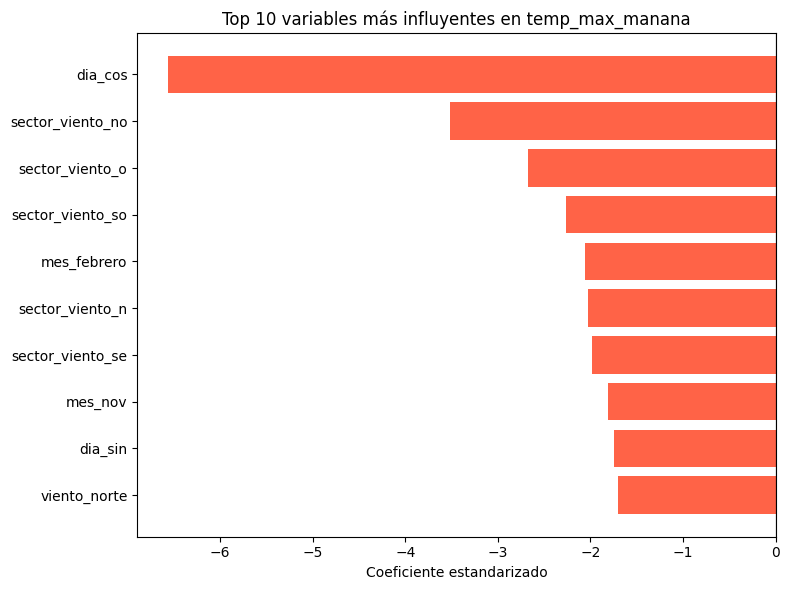

In [ ]:
plt.figure(figsize=(8,6))
top10 = importancia.head(10).sort_values('abs_coef')
colors = ['tomato' if c < 0 else 'seagreen' for c in top10['coeficiente']]
plt.barh(top10['variable'], top10['coeficiente'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente estandarizado')
plt.title('Variables mas influyentes en temp_max_manana')
plt.tight_layout()
plt.show()

**5 variables mas influyentes:**

| Variable | Coeficiente | Interpretación |
|---|---|---|
| `dia_cos` | -6.57 | Componente ciclica del día del año, que es el mayor peso del modelo |
| `sector_viento_no` | -3.52 | Viento del noroeste asociado a temperaturas mas bajas |
| `sector_viento_o` | -2.68 | Viento del oeste, mismo efecto que el anterior |
| `sector_viento_so` | -2.26 | Viento del suroeste |
| `mes_febrero` | -2.05 | Efecto estacional propio de febrero |



Las variables con mayor peso absoluto son `dia_cos` que es la componente cíclica del día 
del año, seguida de varias categorías de `sector_viento` y del mes (`febrero`, `nov`, `sept`, `aug`, `jun`). La variable `humedad_desv` también es de las más relevantes (1.51), lo cual es consistente con lo observado en el mapa de calor de correlaciones de la sección 3.6.

**Hallazgo importante:** se observa que la variable `mes` sigue conteniendo categorias en ingles sin traducir (`nov`, `sept`, `aug`, `jun`) a pesar del proceso de normalización de texto aplicado en la sección 4. Esto sugiere que el diccionario de mapeo usado no cubrió todas las variantes de idioma/abreviación identificadas en la exploración inicial.

### 9. Verificacion de los supuestos de regresión lineal

Se valida el cumplimiento de los 4 supuestos sobre el Modelo 2 que fue el que tuvo un mejor desempeño: no multicolinealidad, linealidad, normalidad de los errores y homocedasticidad.

#### 9.1 No multicolinealidad (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer as SI
import statsmodels.api as sm

X_train_num_imputed = pd.DataFrame(SI(strategy='median').fit_transform(X_train[num_cols]), columns=num_cols)

# Se agrega una constante (intercepto) antes de calcular el VIF ya que sin ella el calculo se distorsiona para variables cuya media no es cercana a 0
X_train_num_const = sm.add_constant(X_train_num_imputed)

vif_data = pd.DataFrame()
vif_data['variable'] = X_train_num_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_num_const.values, i) for i in range(X_train_num_const.shape[1])]

vif_data = vif_data[vif_data['variable'] != 'const'].sort_values('VIF', ascending=False)
vif_data

,variable,VIF
13,viento_este,5.345604
12,viento_norte,5.079459
18,direccion_viento_sin,3.653492
19,direccion_viento_cos,3.457555
9,rafaga_media,3.293622
11,rafaga_max,2.853956
17,dia_cos,1.687132
5,humedad_desv,1.683012
10,rafaga_min,1.675252
6,viento_media,1.463471


**Nota tecnica:** el calculo de VIF requiere agregar una constante a la matriz de variables antes de aplicar `variance_inflation_factor` y es que omitir este paso distorsiona el resultado para variables cuya media esta lejos de cero.

Aqui se identifican dos variables con VIF > 4 que son `viento_este` con 5.35 y `viento_norte` con 5.08. 

| Variable | VIF | ¿Problematico? |
|---|---|---|
| `viento_este` | 5.35 | Moderado |
| `viento_norte` | 5.08 | Moderado |
| `direccion_viento_sin/cos` | 3.5-3.7 | No |
| Resto de variables | < 3.3 | No |

Esto es esperable ya que ambas son las componentes ortogonales de la misma magnitud física (velocidad y dirección del viento), por lo que mantienen cierta relacion estructural entre si. Sin embargo, al no superar un VIF de 10 que es el umbral mas permisivo usado en la práctica, no se considera una multicolinealidad critica que requiera eliminar alguna de las dos variables.

**Conclusión: supuesto de no multicolinealidad razonablemente cumplido.**

#### 9.2 Linealidad

Correlacion entre residuos y valores predichos: -0.1115


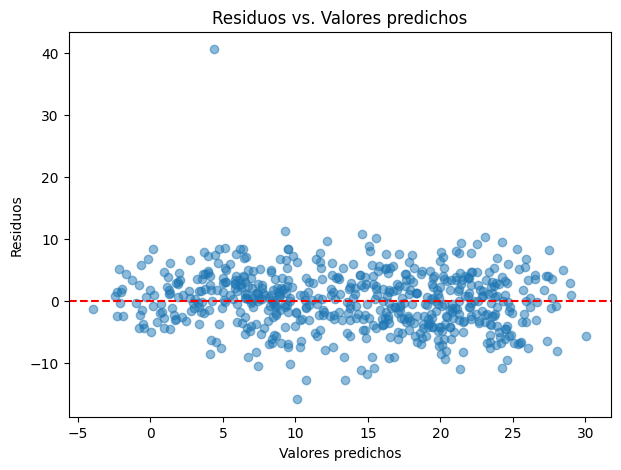

In [60]:
residuos = y_test.values - y_pred_opt
corr_resid_pred = pd.Series(residuos).corr(pd.Series(y_pred_opt))
print(f"Correlacion entre residuos y valores predichos: {corr_resid_pred:.4f}")

plt.figure(figsize=(7,5))
plt.scatter(y_pred_opt, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs. Valores predichos')
plt.show()

- Correlación residuos vs. predichos: **-0.111**
- El grafico no muestra un patron curvo sistematico, los puntos se distribuyen aleatoriamente alrededor de la línea roja (residuo = 0)
- Esto es consistente con el supuesto de linealidad, aunque se observa un valor atipico con residuo de +40°C que se 
analiza más adelante.

#### 9.3 Normalidad de los errores

Shapiro-Wilk: estadistico=0.9482, p-valor=0.000000


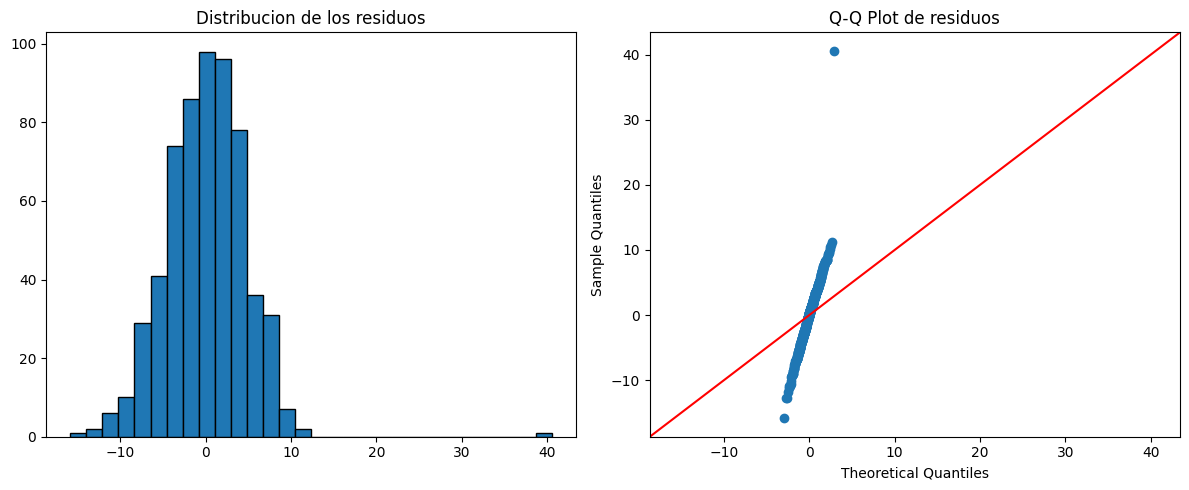

In [57]:
from scipy import stats
import statsmodels.api as sm

shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk: estadistico={shapiro_stat:.4f}, p-valor={shapiro_p:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(residuos, bins=30, edgecolor='black')
axes[0].set_title('Distribucion de los residuos')
sm.qqplot(residuos, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot de residuos')
plt.tight_layout()
plt.show()

| Test | Estadístico | p-valor | Resultado |
|---|---|---|---|
| Shapiro-Wilk | 0.9482 | < 0.001 |Se rechaza H0 de normalidad |

**¿Por qué falla el test si el histograma se ve casi normal?**
El test es muy sensible a valores extremos, y hay un outlier puntual con 
residuo de mas de 40°C que distorsiona el resultado. Tanto el histograma como el Q-Q plot muestran que el grueso de los residuos 
si se ajusta razonablemente a una distribución normal y que el problema esta concentrado en ese unico punto.

**Conexión con la exploración inicial:** este comportamiento es consistente con 
lo detectado en la sección de distribucion de las variables donde se identificaron 10 outliers en 
`temp_max_manana` mediante IQR. Es probable que ese registro especifico no se haya filtrado en la etapa de preparacion del Modelo 2.

Con esto se puede decir que el supuesto de normalidad no se cumple estrictamente aunque el 
incumplimiento se explica por un caso puntual y no por una falla estructural del 
modelo.

#### 9.4 Homocedasticidad

In [59]:
from statsmodels.stats.diagnostic import het_breuschpagan

X_test_transformed = optimized_pipeline.named_steps['preprocessor'].transform(X_test)
X_test_with_const = sm.add_constant(X_test_transformed)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuos, X_test_with_const)
print(f"Breusch-Pagan: estadistico={bp_stat:.4f}, p-valor={bp_pvalue:.6f}")

Breusch-Pagan: estadistico=42.6874, p-valor=0.789757


Vemos que el test de Breusch-Pagan arroja un pvalor de 0.79 > 0.05, por lo que no se rechaza la hipotesis de homocedasticidad.

La varianza de los residuos se mantiene consistente a lo largo de los distintos niveles de la variable predicha, como tambien se observa visualmente en el gráfico de residuos vs. predichos donde la dispersion de puntos no se ensancha ni se estrecha de 
forma sistematica.

**Conclusión general de los supuestos:** 

| Supuesto | ¿Se cumple? | Observación |
|---|---|---|
| No multicolinealidad | si | Ningún VIF supera 10 |
| Linealidad | si | Correlación residuos-predichos = -0.11 (cercana a 0) |
| Normalidad de errores | parcial | Falla por un unico outlier puntual |
| Homocedasticidad | si | p-valor = 0.80 en Breusch-Pagan |

### Analisis de resultados

**1. ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?**

El mejor modelo concluimos que es el segundo, el cual es una regresion lineal que tiene un intercepto de 16.39°C, este valor representa como tal la prediccion del modelo en el caso base que es cuando todas las variables numericas estan en su promedio y las 
variables categoricas estan en su categoría de referencia. Es decir que este intercepto del modelo es la temperatura maxima esperada para un dia de condiciones climaticas promedio, en invierno, en abril y con viento del este.

A partir de ese punto cada coeficiente que se hallo anteriormente con mayor peso en la seccion 8 indica cuanto se aleja la prediccion 
segun los valores reales del dia. Para las variables numericas como `dia_cos`, el coeficiente indica el cambio esperado en `temp_max_manana` por cada desviación estándar de cambio en esa variable. Ya para las variables categoricas el coeficiente indica la diferencia respecto a su categoria de referencia explicada arriba.

Algo que se detecto tambien fue que al revisar las categorias originales de `mes`, se encontr que la normalizacióode texto aplicada en la etapa de preparacion fue incompleta ya que en lugar de 12 categorías (una por mes), quedaron en total 24 categorias distintas,  donde se mezcla español, abreviaturas en ingles y variantes sin unificar. Por ejemplo `sept`, `septiembre`, `sep` deberían ser una sola categoria que corresponderia al mes de septiembre, por lo que esto duplica de forma innecesaria el numero de variables dummy generadas por el mes. Se recomienda como mejora corregir el diccionario de mapeo de meses antes de una futura iteracion.

**2. A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?**

Segun la tabla presentada en la comparacion, el modelo 2 ofrece un mejor rendimiento sobre el conjunto de prueba en las tres metricas que se evaluaron.

- **RMSE** se reduce de 6.31°C a 4.70°C (mejora del 25.5%)
- **MAE** se reduce de 5.01°C a 3.59°C (mejora del 28.3%)
- **R²** aumenta de 0.477 a 0.710

Interpretacion que le damos a estos coeficientes:

- **MAE (Error Absoluto Medio):** Esta es la metrica mas directa de interpretar ya que esta en las mismas unidades que 
la variable objetivo (que es en °C) y no penaliza mas los errores grandes que los pequeños.Segun el resultado, en promedio las predicciones del modelo 2 se equivocan en 3.59°C respecto a la temperatura maxima real del dia siguiente.

- **RMSE (Raíz del Error Cuadrático Medio):** también está en °C pero al elevar los errores al cuadrado antes de promediarlos penaliza mas fuerte los errores grandes. Esto nos indica que el RMSE sea mayor que el MAE confirma que existen algunos dias con errores de prediccion notablemente mas grandes que el promedio como el outlier de +40°C identificado en la sección 9.3, que arrastran 
el RMSE hacia arriba.

- **R² (Coeficiente de determinacion):** Este indica que proporcion de la variabilidad de `temp_max_manana` es explicada por el modelo. Que el coeficiente de determinacion sea 0.710 significa que el modelo 2 explica el 71% de la variabilidad de la temperatura maxima del día siguiente a partir de las variables meteorologicas disponibles, dejando un 29% sin explicar.

Es decir que la mejora del modulo 2 representa una reduccion de error y casi 23 puntos porcentuales mas de capacidad explicativa, lo que valida que el uso y las decisiones aplicadas que tomamos sobre las variables ciclicas y eliminacion de multicolinealidad tuvieron un impacto real y medible sobre el modelo.

**3. ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.**

A partir del modelo 2 se identificaron 19 variables numericas y 3 variables categoricas, entre estas y segun la tabla de importancia en la seccion 8 se sacaron las variables con mayor peso predictivo:

1. `dia_cos` (componente ciclica del dia del año): que es la mas influyente de 
todo el modelo
2. `sector_viento` (noroeste, oeste, suroeste, norte, 
sureste): todas con efecto negativo sobre la temperatura del dia siguiente
3. `mes`: sobretodo para los meses de febrero, noviembre, septiembre, agosto
4. `humedad_desv`: Esta es la unica variable numerica que no es ciclica entre las 5 mas relevantes

Entonces el hallazgo mas importante es que la direccion del viento tiene un peso comparable o mayor que variables mas obvias por asi decirlo como la humedad o la presion, esto sugiere que la orientacion de las masas de aire influye de forma significativa en la temperatura del dia siguiente.

Aparte de esto la fuerte influencia de `dia_cos` nos confirma que la estacionalidad es el factor dominante en la temperatura, pero el hecho de que `humedad_desv` aparezca entre las mas relevantes es un hallazgo menos obvio lo cual sugiere que la inestabilidad 
de la humedad durante el dia es mas informativa para predecir el dia siguiente que el nivel de humedad en si.

Ya a partir de estos resultados se pueden sacar unas propuestas razonadas a partir del contexto de alpesplanck, por ejemplo lo que nos dice el enunciado en si sobre diseñar estrategias para reducir complicaciones con el fenomeno del niño y de la niña, es sabido que estos fenomenos son conocidos por alterar los vientos y la humedad a una gran escala, entonces que el modelo dependa de estas dos variables como `sector_viento` y `humedad_desv` abre la pregunta de si desviaciones sostenidas en estas variables podrian usarse como un tipo de indicador complementario de anomalias climaticas regionales. otra posibilidad a tener en cuenta seria la alerta a incendios forestales, dado que el secto del viento y la epoca del año son los factores de mayor peso en el modelo podria explorarse 
si su monitoreo conjunto ayuda a anticipar esos dias de mayor riesgo termico.

**4. A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.**

El modelo se representa como una combinacion lineal de las variables predictoras mas un termino de error:

$$temp\_max\_manana = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_m X_m + \varepsilon$$

Donde $\beta_0$ es el intercepto 16.39°C en el modelo 2, $\beta_1, ..., \beta_m$ son los coeficientes asociados a cada una de las 22 
variables predictoras que mencionamos anteriormente que son 19 numericas y las 3 categorias `estacion_anio`, `mes` y `sector_viento`, $X_1, ..., X_m$ son los valores de cada variable y $\varepsilon$ es el termino de error.

El metodo que se utilizo fue la clase LinearRegression de scikit-learn la cual resuelve el problema mediante el metodo de minimos cuadrados ordinarios el cual busca el vector de coeficientes $\theta$ que minimiza la suma de los residuos al cuadrado entre los valores predichos y los reales:

$$\min_{\theta} \; \| X\theta - Y \|^2$$

Este problema tiene una solución cerrada o exacta dada por la ecuación normal $$\theta^* = (X^TX)^{-1}X^TY$$

Lo que nos dice este metodo es que scikit-learn no invierte la matriz $X^TX$ directamente sino que utiliza descomposicin en valores singulares para resolver el sistema de forma mas estable especialmente en este caso dado que se identificaron dos variables con VIF moderado `viento_este` y `viento_norte`

**5. En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.**

A) Sesgo temporal / historico (temporal bias)

Este ocurre cuando el modelo se entrena con datos de un periodo en especifico, y este periodo no representa las condiciones futuras en las que el modelo sera utilizado. El dataset cubre unicamente el periodo de 2009 a 2015 y un modelo entrenado sobre estos años asume que los patrones climaticos de esa ventana temporal seguira siendo validos en el futuro.

Esto es relevante para el resultado dado el objetivo de anticipar fenomenos como el niño y la niña o cambios en los patrones de incendios forestales. Si el clima regional esta siendo afectado por tendencias de cambio climatico a largo plazo, un modelo entrenado solo con datos del periodo mencionado podria fallar en capturar la frecuencia real de eventos climaticos extremos que se han vuelto mas comunes con el tiempo.

B) Sesgo de medicion (measurement bias)

Este sesgo pasa cuando los instrumentos o el proceso de captura de los datos tienen errores sistematicos en lugar de reflejar la realidad que se busca medir. Este proyecto presenta evidencia de este tipo de sesgo ya que se identifico un valor centinela muy irregular de -9999 en `rafaga_min`, que es usado para marcar datos faltantes pero se mezcla con los valores reales sin diferenciarse como nulo, tambien presenta valores fisicamente imposibles como una presion de 9,939 mbar o una temperatura de 63°C.

Si estos errores de medicion no se identifican y se corrigen desde la etapa de preparacion, el modelo aprende de datos que estan fuera de la realidad lo que puede sesgar los coeficientes estimados y reducir tanto la precisión como la interpretacion del modelo. Un ejemplo que vimos en la seccion 9.3, el outlier de +40°C en los residuos del modelo 2 que hizo fallar el test de normalidad, esto significo que un registro de `temp_max_manana` no fue depurado en la etapa de preparacion.


### Declaración uso de IA Generativa
Para el desarrollo de este proyecto nos apoyamos en el uso de IAG (Gemini) para lo siguiente:
* Herramienta para el análisis de la tabla resultante por data.describe(), esto nos ayudó a corroborar nuestras abstracciones propias y, además nos proveyó de otras nuevas. Los prompts asociados a este punto también sirvieron para entender los rangos esperados de las variables metereológicas dadas las propiedas físicas de los mismos.
    * https://share.gemini.google/1kUd2vxyPTqO
* Como en una de las primeras secciones, fueron las conversaciones con estas herramientas de IA las que nos permitieron entender la naturaleza cíclica de las variables `dial_del_anio` y `direccion_viento` y cómo calcular el seno y el coseno de estos podría ser una decisión de ingeniería de datos apropiada para nuestro caso.
    * https://share.gemini.google/04gyGQjeoB2k
* La IA también nos ayudó con la corrección del código y guias para el desarrollo del propio.

Ademas de esto se uso la herramiento de IAG (claude) para la verificacion del analisis de importancia de variables y la validacion de los 4 supuestos de regresión lineal (VIF, linealidad, normalidad, homocedasticidad) sobre el modelo 2.
* Con esta ayuda se detecto un error en el calculo inicial del VIFal omitir agregar una constante (intercepto) a la matriz antes del calculo, es decir que tres variables (`anio`, `presion_media`, `registros_del_dia`) mostraban VIFs artificialmente altos, lo cual habria llevado a una conclusion erronea con respecto a la multicolinealidad severa.